In [2]:
import pandas as pd 

import numpy as np

In [3]:
df = pd.read_csv('coffee_shop_sales.csv')

In [4]:
df.head()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


In [5]:
df.shape

(20000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-null  bool   
 16  weat

In [7]:
df.isnull().sum()

transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

In [8]:
# fill in missing values
df['customer_age_group'] = df['customer_age_group'].fillna('Unknown')
df['customer_gender'] = df['customer_gender'].fillna('Unknown')
df['weather_condition'] = df['weather_condition'].fillna('Unknown')
df['holiday_name'] = df['holiday_name'].fillna('None')

# Fill numeric missing values
df['temperature_c'] = df['temperature_c'].fillna(df['temperature_c'].median())


The replacement of missing values in the database involves filling gaps in a way that ensures the consistent and usability of the data. In the situation of categorical variables such as customer_age_group, customer_gender, and weather_condition, the filling the missing value process was done using the value "Unknown," therfore avoiding the exclusion of rows and indicating the absence of the data point. In the field of holiday_name, where data was missing from almost the whole dataset, the process was carried out through adding in the value "None," telling us the fact that most transactions were made in a period where no holidays took place. Finally, the missing values in the numerical variable, temperature_c, were filled using the median value.

# Descriptive Questions


How do people’s demographics, store characteristics, and weather conditions affect global sales?
- When are the most drinks sold?
- Most popular drink by gender? age?
- Do more drinks get sold on a holiday?
- Under what weather conditions do the most drinks get sold?


C:\Users\Nikhil-Gaming\AppData\Local\Temp\ipykernel_28136\1343657683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='customer_age_group', y='total_amount', order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+',], estimator='mean', errorbar=None, palette="viridis")


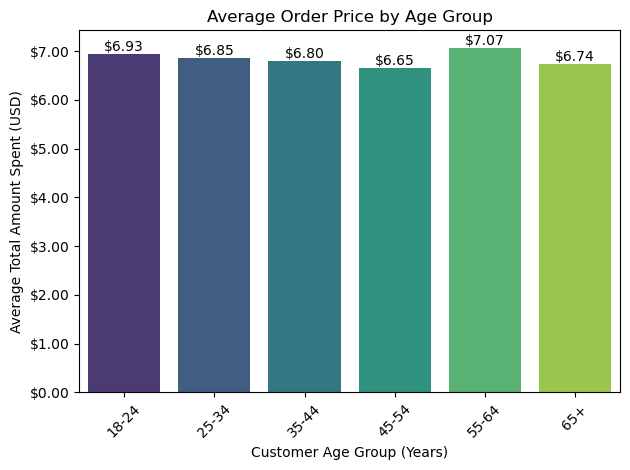

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.barplot(data=df, x='customer_age_group', y='total_amount', order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+',], estimator='mean', errorbar=None, palette="viridis") 
for container in plt.gca().containers: #adding $ to each bar
    plt.bar_label(container, fmt='$%.2f')
plt.gca().yaxis.set_major_formatter('${x:1.2f}') #adding $ to y-axis
plt.title("Average Order Price by Age Group")
plt.xlabel("Customer Age Group (Years)")
plt.ylabel("Average Total Amount Spent (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

# Description
This chart shows the mean total spending made by the customers belonging to various age groups. Each bar shows the average cost of an order aquired by a customer from each age group per transaction.
# Results
In the results the graph shows us a clear age demographic in spending across age groups. Some age groups spend a bit more per transaction, while others spend less. Typically, older age groups tend to have slightly higher average spending, while younger groups may spend less per visit.
# Our interpretation 

## By Gender

In [10]:
df_filtered = df[df['customer_gender'] != 'Unknown'] #Remove rows with unknown gender

C:\Users\Nikhil-Gaming\AppData\Local\Temp\ipykernel_28136\1389511537.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Gender Distribution')

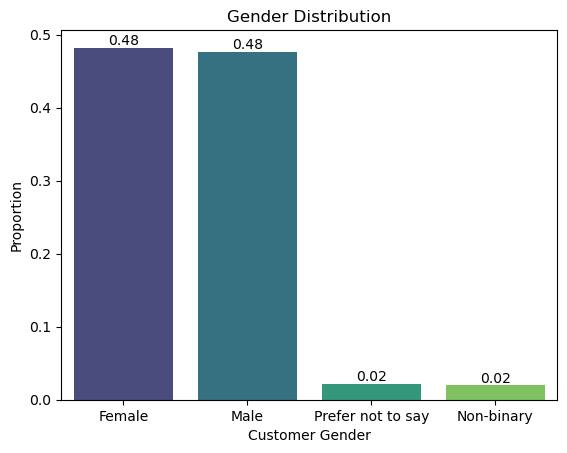

In [11]:
# Gender Statistics

counts = df_filtered['customer_gender'].value_counts(normalize=True)

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='viridis'
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f')

plt.ylabel("Proportion")
plt.xlabel("Customer Gender")
plt.title("Gender Distribution")

C:\Users\Nikhil-Gaming\AppData\Local\Temp\ipykernel_28136\222048180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtered, x='customer_gender', y='total_amount', estimator='mean', errorbar=None, palette="viridis")


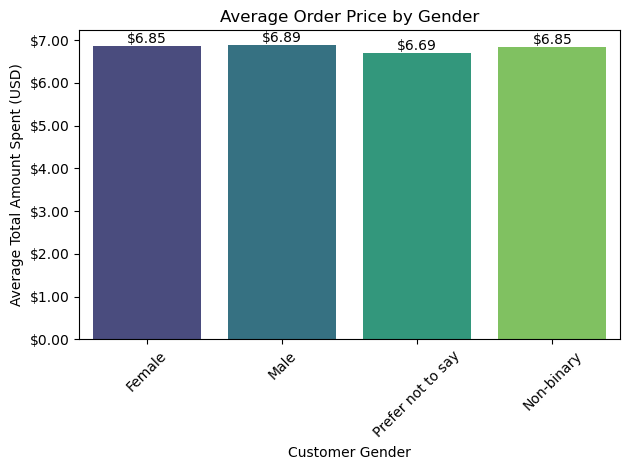

In [12]:
#Order Price by Gender



sns.barplot(data=df_filtered, x='customer_gender', y='total_amount', estimator='mean', errorbar=None, palette="viridis") 
for container in plt.gca().containers: #adding $ to each bar
    plt.bar_label(container, fmt='$%.2f')
plt.gca().yaxis.set_major_formatter('${x:1.2f}') #adding $ to y-axis
plt.title("Average Order Price by Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Average Total Amount Spent (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

Most popular orders for Female:
Croissant: 317
Scone: 311
Medium Latte: 311

Most popular orders for Male:
Medium Americano: 306
Medium Cappuccino: 305
Double Espresso: 303

Most popular orders for Prefer not to say:
Small Latte: 21
Large Latte: 17
Chicken & Avocado Wrap: 17

Most popular orders for Non-binary:
Chicken & Avocado Wrap: 19
Small Americano: 16
Medium Latte: 15



C:\Users\Nikhil-Gaming\AppData\Local\Temp\ipykernel_28136\2607175143.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


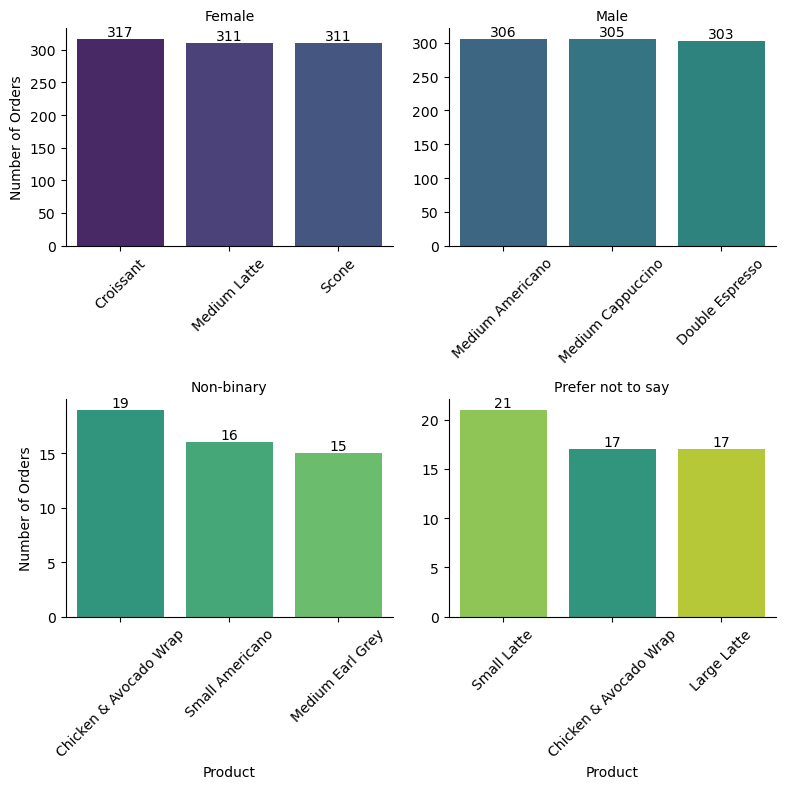

In [13]:
# Find the most popular drink by gender

for gender in df_filtered['customer_gender'].unique():
    print(f"Most popular orders for {gender}:")
    top_items = df_filtered[df_filtered['customer_gender'] == gender]['product_name'] \
    .value_counts().head(3)
    for item, count in top_items.items():
        print(f"{item}: {count}")
    print()



top_products = (
    df_filtered
    .groupby('customer_gender')['product_name']
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name='count')
)

g = sns.catplot(
    data=top_products,
    x='product_name',
    y='count',
    col='customer_gender',
    kind='bar',
    col_wrap=2,
    sharex=False,
    sharey=False,
    palette='viridis',
    height=4
)

g.set_titles("{col_name}")
g.set_axis_labels("Product", "Number of Orders")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

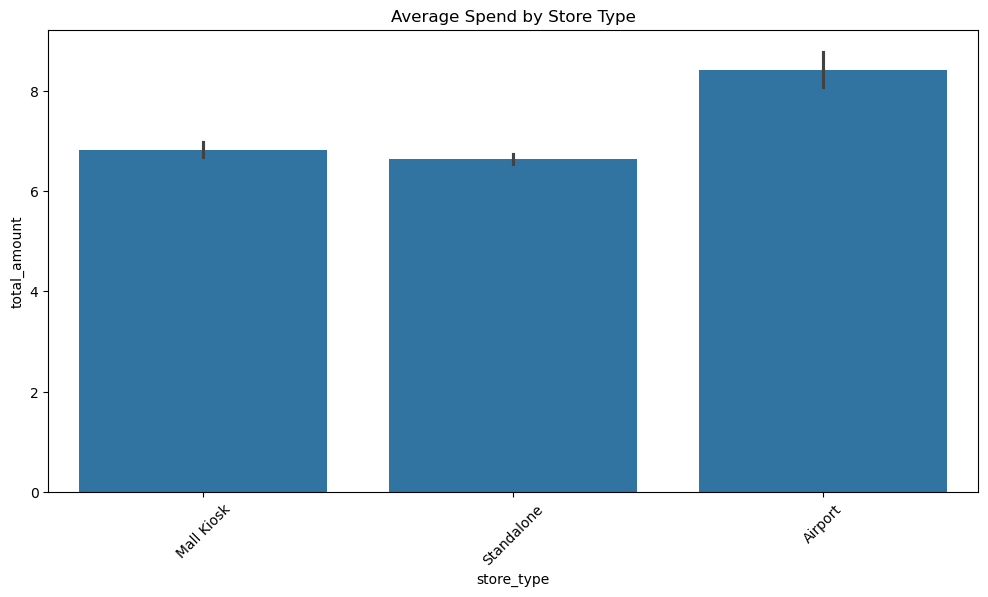

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='store_type', y='total_amount', estimator='mean')
plt.title("Average Spend by Store Type")
plt.xticks(rotation=45)
plt.show()

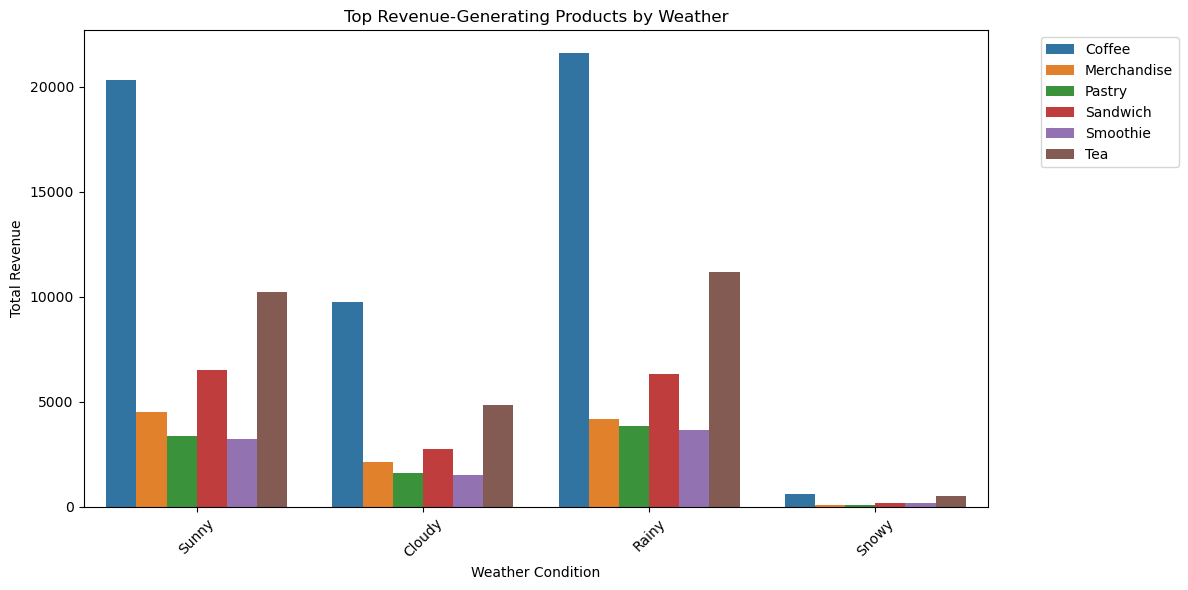

In [39]:
# Top Products by weather condition

top_weather_products = (
    df_filtered
    .groupby(['weather_condition', 'product_category'], as_index=False)['total_amount']
    .sum()
)

weather_order = ['Sunny', 'Cloudy', 'Rainy', 'Snowy']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_weather_products,
    x='weather_condition',
    y='total_amount',
    hue='product_category',
    order=weather_order
)

plt.title("Top Revenue-Generating Products by Weather")
plt.ylabel("Total Revenue")
plt.xlabel("Weather Condition")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


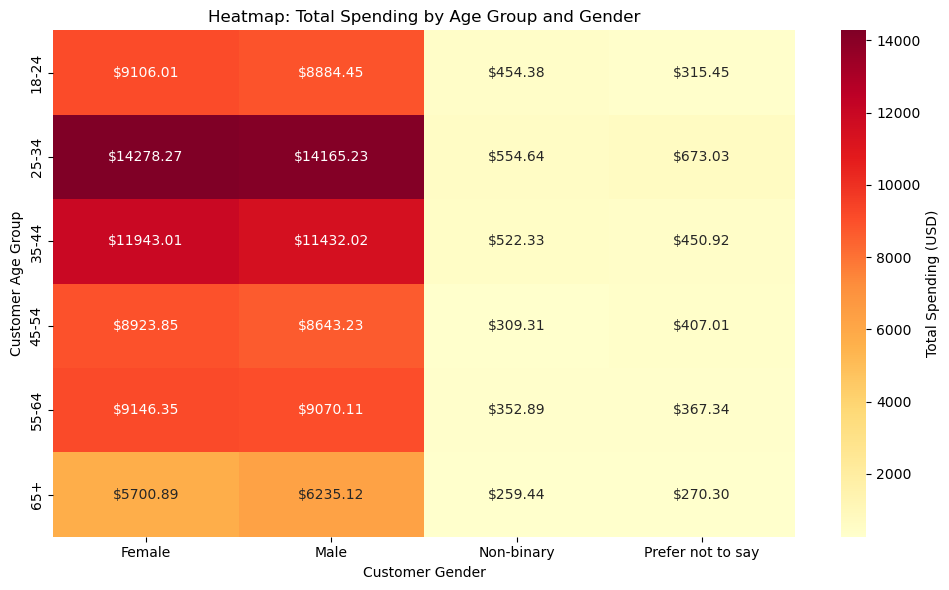


Highest Spending Combination: 25-34 (Gender: Female) - $14,278.27


In [20]:
# Heatmap: Total Spending by Age Group and Gender

# Create a crosstab showing total spending across age groups and genders
spending_pivot = pd.crosstab(
    df['customer_age_group'],
    df_filtered['customer_gender'],
    values=df['total_amount'],
    aggfunc='sum'
)

# Reorder age groups logically
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
spending_pivot = spending_pivot.reindex([age for age in age_order if age in spending_pivot.index]) 

# Create heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(data = spending_pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Total Spending (USD)'})
for t in ax.texts:
    t.set_text('$' + t.get_text())
plt.title("Heatmap: Total Spending by Age Group and Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Customer Age Group")
plt.tight_layout()
plt.show()

# Find the age group and gender combination with highest spending
max_spending_idx = spending_pivot.stack().idxmax()
max_spending_value = spending_pivot.stack().max()
print(f"\nHighest Spending Combination: {max_spending_idx[0]} (Gender: {max_spending_idx[1]}) - ${max_spending_value:,.2f}")

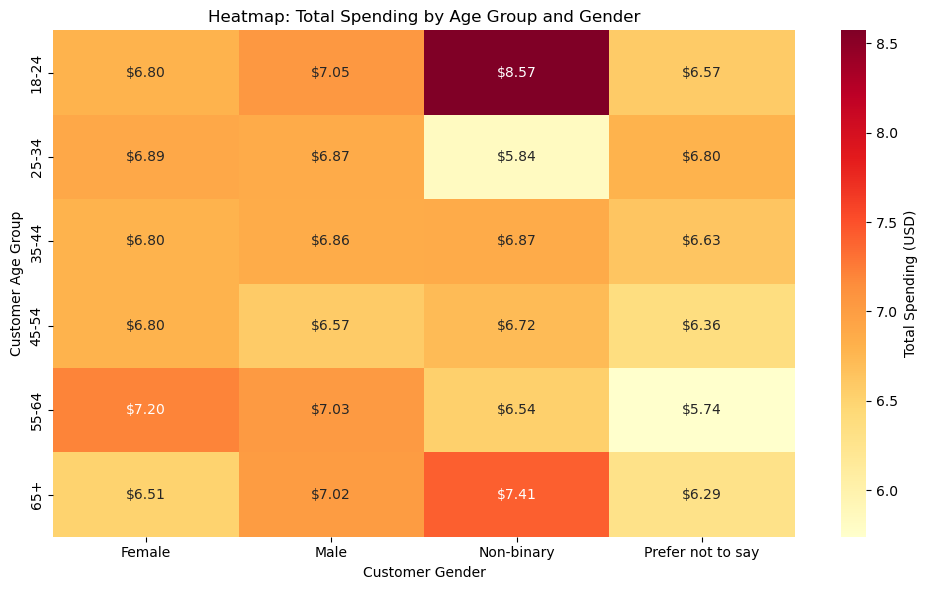


Highest Spending Per Order: 18-24 (Gender: Non-binary) - $8.57


In [22]:
# Create a crosstab showing total spending across age groups and genders
spending_pivot = pd.crosstab(
    df['customer_age_group'],
    df_filtered['customer_gender'],
    values=df['total_amount'],
    aggfunc='mean'
)

spending_pivot = spending_pivot.reindex([age for age in age_order if age in spending_pivot.index]) 

# Create heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(data = spending_pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Total Spending (USD)'})
for t in ax.texts:
    t.set_text('$' + t.get_text())
plt.title("Heatmap: Total Spending by Age Group and Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Customer Age Group")
plt.tight_layout()
plt.show()

# Find the age group and gender combination with highest spending
max_spending_idx = spending_pivot.stack().idxmax()
max_spending_value = spending_pivot.stack().max()
print(f"\nHighest Spending Per Order: {max_spending_idx[0]} (Gender: {max_spending_idx[1]}) - ${max_spending_value:,.2f}")